# Feedforward Neural Networks and Backpropagation

**Alumno:** Javier Ramirez  
**CICESE**  
**Foundations of Deep Learning**  
**Assignment 1**  
**Due date:** February 18, 2026  
**Instructor:** Jesús Guillermo Falcón-Cardona

#  Datasets


In [1]:
! pip install ucimlrepo -q

In [1]:
from ucimlrepo import fetch_ucirepo 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import math

In [2]:
# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
X = iris.data.features 
y = iris.data.targets 
  
# metadata 
print(iris.metadata) 
  
# variable information 
print(iris.variables) 


{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

In [ ]:
# save in a dataframe
df_iris = pd.DataFrame(X, columns=iris.data.feature_names)
df_iris['target'] = y
print(df_iris.head())

   sepal length  sepal width  petal length  petal width       target
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [4]:
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables) 

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [ ]:
# save in a dataframe
df_breast_cancer = pd.DataFrame(X, columns=breast_cancer_wisconsin_diagnostic.data.feature_names)
df_breast_cancer['target'] = y
print(df_breast_cancer.head())

   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  texture3  \
0      0.3001          0.14710     0.2419             0.07871  ...     17.33   
1      0.0869          0.07017     0.1812             0.05667  ...     23.41   
2      0.1974          0.12790     0.2069             0.05999  ...     25.53   
3      0.2414          0.10520     0.2597             0.09744  ...     26.50   
4      0.1980          0.10430     0.1809             0.05883  ...     16.67   

   perimeter3   area3  smoothness3  compactness3  concavity3  concave_points3  \
0      184.

In [ ]:
#iris dataset

# nombres de columnas de dataset iris
print("Las columnas del dataset iris son:")
print(df_iris.columns)

# cantidad de columnas de dataset iris
columns_iris = len(df_iris.columns)

n_input_iris = columns_iris - 1

print("El número de unidades de entrada para el dataset iris es:") # -1 para no contar la columna de target
print(n_input_iris)

# número de unidades de salida (i.e número de clases) para el dataset iris
n_output_iris = len(df_iris['target'].unique())
print("El número de unidades de salida para el dataset iris es:")
print(n_output_iris)


print ("las clases del dataset iris son:")
print(df_iris['target'].unique())

Las columnas del dataset iris son:
Index(['sepal length', 'sepal width', 'petal length', 'petal width', 'target'], dtype='object')
El número de unidades de entrada para el dataset iris es:
4
El número de unidades de salida para el dataset iris es:
3
las clases del dataset iris son:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [ ]:
#breast cancer dataset

# nombres de columnas de dataset breast cancer
print("Las columnas del dataset breast cancer son:")
print(df_breast_cancer.columns)

# cantidad de columnas de dataset breast cancer
columns_breast_cancer = len(df_breast_cancer.columns)

n_input_breast_cancer = columns_breast_cancer - 1

print("El número de unidades de entrada para el dataset breast cancer es:") # -1 para no contar la columna de target
print(n_input_breast_cancer)

# número de unidades de salida (i.e número de clases) para el dataset breast cancer
n_output_breast_cancer = len(df_breast_cancer['target'].unique())
print("El número de unidades de salida para el dataset breast cancer es:")
print(n_output_breast_cancer)

# las clases del dataset breast cancer
print ("las clases del dataset breast cancer son:")
print(df_breast_cancer['target'].unique())


Las columnas del dataset breast cancer son:
Index(['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3', 'target'],
      dtype='object')
El número de unidades de entrada para el dataset breast cancer es:
30
El número de unidades de salida para el dataset breast cancer es:
2
las clases del dataset breast cancer son:
['M' 'B']


# Softmax

La función Softmax es una función de activación ampliamente utilizada en la capa de salida de redes neuronales diseñadas para tareas de clasificación multiclase. Su objetivo es transformar un vector de logits —es decir, puntuaciones reales no normalizadas generadas por el modelo antes de aplicar cualquier activación— en una distribución de probabilidad.

En particular, Softmax convierte estos valores arbitrarios en probabilidades interpretables, donde cada componente del vector resultante toma valores en el intervalo 
(0,1)
(0,1) y la suma total de sus elementos es igual a 1. De este modo, cada salida puede interpretarse como la probabilidad estimada de que la muestra pertenezca a una clase específica.

Esta propiedad permite seleccionar la clase más probable mediante el operador argmax y facilita el uso de funciones de pérdida probabilísticas, como la entropía cruzada, durante el entrenamiento.

---

Para un vector $\mathbf{z}$ de longitud $K$, la función Softmax aplicada al elemento $i$-ésimo se define como:

$$
\text{softmax}(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

Esta fórmula eleva cada entrada $z_i$ a la exponencial y posteriormente la normaliza dividiendo por la suma de todas las exponenciales.

De esta manera:

- Todos los valores resultantes son positivos.
- La suma total de los elementos es igual a 1.
- El vector resultante puede interpretarse como una distribución de probabilidad sobre $K$ clases.

Se utiliza una versión estable:

$$
\text{softmax}(\mathbf{z})_i = 
\frac{e^{z_i - \max(\mathbf{z})}}
{\sum_{j=1}^{K} e^{z_j - \max(\mathbf{z})}}
$$

Restar el valor máximo del vector no altera el resultado final debido a que:

$$
\frac{e^{z_i - c}}{\sum_{j} e^{z_j - c}}
=
\frac{e^{z_i} e^{-c}}{e^{-c} \sum_{j} e^{z_j}}
=
\frac{e^{z_i}}{\sum_{j} e^{z_j}}
$$

Esta transformación evita problemas de desbordamiento numérico cuando los valores de entrada son grandes, ya que impide que la función exponencial crezca hacia infinito.

---


In [ ]:
class Softmax:
    def forward(self, Z):
        """
        Z: matriz (n_clases, m)
        Convierte un vector de logits (valores reales) en un vector de
        probabilidades que suman 1.
        """
        Z_shift = Z - np.max(Z, axis=0, keepdims=True)
        exp_Z = np.exp(Z_shift)
        return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)


# Cross-Entropy

La entropía cruzada es una función de pérdida utilizada para medir qué tan diferente es la distribución de probabilidad predicha por un modelo respecto a la distribución real de los datos. En problemas de clasificación, el modelo no produce directamente una clase, sino una distribución de probabilidades sobre las posibles clases. La entropía cruzada cuantifica el “costo” asociado a asignar probabilidades incorrectas a las clases verdaderas.

Desde el punto de vista probabilístico, si denotamos por $p$ la distribución verdadera y por $q$ la distribución estimada por el modelo, la entropía cruzada se define como

$$
H(p, q) = - \sum_{k=1}^{K} p_k \log q_k
$$

Esta expresión puede interpretarse como el valor esperado del logaritmo negativo de la probabilidad predicha. Intuitivamente, penaliza fuertemente aquellas situaciones en las que el modelo asigna una probabilidad pequeña a la clase correcta.

En clasificación supervisada, las etiquetas reales suelen representarse como vectores one-hot. En ese caso, todos los componentes $p_k$ son cero excepto el correspondiente a la clase correcta, que vale 1. Esto simplifica la expresión anterior a

$$
L = - \log q_{y}
$$

donde $q_{y}$ es la probabilidad que el modelo asigna a la clase verdadera. Por lo tanto, la pérdida depende únicamente de qué tan grande sea la probabilidad asignada a la clase correcta.

Ejemplo simple de one-hot encoding:

Supongamos un problema con 3 clases posibles (Iris).  
Si la clase correcta es la tercera, su representación one-hot es:

$$
[0, 0, 1]
$$

### Binary Cross-Entropy

Binary Cross-Entropy se utiliza cuando el problema tiene únicamente dos clases. En este caso, el modelo produce una sola probabilidad $p$, generalmente mediante una función sigmoide, que representa la probabilidad de pertenecer a la clase positiva. La función de pérdida se define como

$$
L = - \left[ y \log(p) + (1 - y) \log(1 - p) \right]
$$

donde $y \in \{0,1\}$ es la etiqueta real. Esta formulación proviene directamente de la verosimilitud de una variable aleatoria Bernoulli y penaliza con mayor intensidad aquellas predicciones que asignan baja probabilidad a la clase correcta.

### Categorical Cross-Entropy

Categorical Cross-Entropy se utiliza en problemas de clasificación multiclase cuando las etiquetas están representadas en formato one-hot. El modelo produce un vector de probabilidades mediante una función softmax, y la pérdida se calcula como

$$
L = - \sum_{k=1}^{K} y_k \log(\hat{p}_k)
$$

donde $y_k$ indica si la clase $k$ es la correcta y $\hat{p}_k$ es la probabilidad predicha para esa clase. Debido a la representación one-hot, esta expresión también se reduce a

$$
L = - \log(\hat{p}_{y})
$$

pero requiere que las etiquetas estén codificadas explícitamente como vectores de dimensión $K$.

### Sparse Categorical Cross-Entropy

Sparse Categorical Cross-Entropy es matemáticamente equivalente a Categorical Cross-Entropy, pero se utiliza cuando las etiquetas reales están representadas como números enteros que indican el índice de la clase correcta, por ejemplo $0, 1, 2$. En lugar de usar vectores one-hot, simplemente se selecciona la probabilidad correspondiente a la clase verdadera.

En este caso, la función de pérdida se calcula como

$$
L = - \log(\hat{p}_{target})
$$

donde $\hat{p}_{target}$ es la probabilidad que el modelo asigna directamente a la clase correcta.

La ventaja de Sparse Categorical Cross-Entropy es que evita la conversión explícita a one-hot, lo que reduce el consumo de memoria y simplifica el cálculo cuando el número de clases es grande. Conceptualmente, el objetivo es exactamente el mismo: maximizar la probabilidad asignada a la clase verdadera.

---

La razón por la cual se utiliza la entropía cruzada en lugar de otras funciones de pérdida es su fundamento en la teoría de la información y en la estimación por máxima verosimilitud. Cuando se combina con funciones de activación como softmax o sigmoide, produce gradientes bien definidos que facilitan el entrenamiento mediante descenso por gradiente.

Desde otra perspectiva, la entropía cruzada puede descomponerse como

$$
H(p, q) = H(p) + D_{KL}(p \parallel q)
$$

donde $H(p)$ es la entropía de la distribución verdadera y $D_{KL}$ es la divergencia de Kullback-Leibler entre la distribución real y la estimada. Como $H(p)$ es constante respecto a los parámetros del modelo, minimizar la entropía cruzada equivale a minimizar la divergencia KL. El entrenamiento busca que la distribución estimada $q$ se aproxime lo más posible a la distribución verdadera $p$.

Si el modelo asigna una probabilidad alta a la clase correcta, la pérdida será pequeña porque $-\log(q_y)$ será cercano a cero. En cambio, si asigna una probabilidad baja, el término logarítmico crece rápidamente en magnitud negativa y la pérdida aumenta considerablemente. Esto genera una penalización fuerte para predicciones incorrectas con alta confianza, lo que incentiva al modelo a producir probabilidades calibradas y coherentes.

La entropía cruzada no solo mide error de clasificación, sino también calidad probabilística. No se limita a evaluar si la predicción es correcta o incorrecta, sino qué tan segura es esa predicción, convirtiéndola en una función de pérdida especialmente adecuada para modelos probabilísticos en aprendizaje profundo.

ref: - https://pub.towardsai.net/how-did-binary-cross-entropy-loss-come-into-existence-68e38509d2b

---


In [ ]:
class CrossEntropyLoss:
    """
    Binary Cross-Entropy (clasificación binaria)
    Sparse Categorical Cross-Entropy (multiclase con índices)
    Categorical Cross-Entropy (multiclase con one-hot)
    """

    def __init__(self, epsilon=1e-15):
        """
        epsilon: pequeño valor para estabilidad numérica
        """
        self.epsilon = epsilon

    # -------------------------------------------------
    # ONE HOT ENCODING
    # -------------------------------------------------
    
    def one_hot(self, y, num_classes):
        """
        Convierte etiquetas enteras en vectores one-hot.

        Parámetros:
        y (int o lista/array de ints)
        num_classes (int): número total de clases

        Retorna:
        np.array: matriz one-hot
        """
        y = np.array(y).flatten()
        one_hot_matrix = np.zeros((len(y), num_classes))
        one_hot_matrix[np.arange(len(y)), y] = 1
        return one_hot_matrix

    # -------------------------------------------------
    # BINARY CROSS-ENTROPY
    # -------------------------------------------------
    
    def binary(self, y_real, y_pred):
        """
        Binary Cross-Entropy

        y_real: 0 o 1
        y_pred: probabilidad (salida sigmoide)
        """
        y_pred = max(self.epsilon, min(1 - self.epsilon, y_pred))

        loss = -(y_real * math.log(y_pred) +
                 (1 - y_real) * math.log(1 - y_pred))

        return loss

    # -------------------------------------------------
    # SPARSE CATEGORICAL CROSS-ENTROPY
    # -------------------------------------------------
    
    def sparse_categorical(self, y_true_idx, y_pred_probs):
        """
        y_true_idx: índice entero de clase
        y_pred_probs: vector de probabilidades (softmax)
        """
        p_target = y_pred_probs[y_true_idx]
        p_target = max(self.epsilon, p_target)

        loss = -math.log(p_target)
        return loss

    # -------------------------------------------------
    # CATEGORICAL CROSS-ENTROPY (ONE-HOT)
    # -------------------------------------------------
    
    def categorical(self, y_one_hot, y_pred_probs):
        """
        Categorical Cross-Entropy

        y_one_hot: vector one-hot
        y_pred_probs: vector de probabilidades (softmax)
        """
        y_pred_probs = np.clip(y_pred_probs,
                               self.epsilon,
                               1 - self.epsilon)

        loss = -np.sum(y_one_hot * np.log(y_pred_probs))
        return loss


# Activation Functions

Las funciones de activación introducen no linealidad en las redes neuronales. Sin ellas, la composición de múltiples capas lineales sería equivalente a una única transformación lineal, lo que impediría al modelo aproximar funciones complejas. 

### ReLU (Rectified Linear Unit)

ReLU es una función lineal por partes que se ha convertido en la activación estándar en capas ocultas de redes profundas debido a su simplicidad computacional y su eficiencia durante el entrenamiento.

Se define matemáticamente como

$$
f(z) = \max(0, z)
$$

Si la entrada $z$ es positiva, la función devuelve el mismo valor; si es negativa o cero, devuelve 0. Esto genera una activación dispersa, ya que muchas neuronas pueden quedar inactivas.

La derivada de ReLU es

$$
f'(z) =
\begin{cases}
1 & \text{si } z > 0 \\
0 & \text{si } z \le 0
\end{cases}
$$

Una de sus principales ventajas es que, en la región positiva, el gradiente es constante e igual a 1. Esto ayuda a mitigar el problema del desvanecimiento del gradiente, permitiendo una propagación más estable del error durante el entrenamiento. Pero, si una neurona recibe siempre valores negativos, puede quedar permanentemente inactiva, fenómeno conocido como neurona muerta.

### Sigmoid

La función Sigmoid fue históricamente una de las primeras funciones de activación utilizadas en redes neuronales. Produce una curva suave en forma de S que comprime cualquier número real en el intervalo abierto $(0,1)$.

Su expresión:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Debido a que su salida está acotada entre 0 y 1, es especialmente útil en la capa de salida de problemas de clasificación binaria, donde puede interpretarse como una probabilidad.

Su derivada puede expresarse en términos de la propia función:

$$
\frac{d\sigma}{dz} = \sigma(z) \left(1 - \sigma(z)\right)
$$

La función presenta un problema, y es que para valores grandes positivos o negativos de $z$, la función se satura, lo que implica que su derivada tiende a cero. Esto provoca el problema del desvanecimiento del gradiente en redes profundas, dificultando el aprendizaje en capas anteriores.

### LeakyReLU

LeakyReLU es una variante de ReLU diseñada para resolver el problema de las neuronas muertas. En lugar de anular completamente los valores negativos, introduce una pequeña pendiente en esa región.

Se define como

$$
f(z) = \max(\alpha z, z)
$$

donde $\alpha$ es un hiperparámetro pequeño, típicamente 0.01 o 0.2.

Puede expresarse como:

$$
f(z) =
\begin{cases}
z & \text{si } z > 0 \\
\alpha z & \text{si } z \le 0
\end{cases}
$$

Su derivada es:

$$
f'(z) =
\begin{cases}
1 & \text{si } z > 0 \\
\alpha & \text{si } z \le 0
\end{cases}
$$

La principal ventaja de LeakyReLU es que garantiza un gradiente distinto de cero en todo el dominio. Esto permite que las neuronas que reciben valores negativos sigan actualizando sus pesos y evita que queden permanentemente inactivas.

---

Las funciones de activación no lineales permiten que la red construya representaciones jerárquicas y modele relaciones complejas entre variables, por lo que la elección de la función de activación influye directamente en la velocidad de convergencia, la estabilidad del entrenamiento y la capacidad de generalización del modelo.

---

In [53]:
class ActivationFunction:

    def __init__(self, name="relu", alpha=0.01):
        self.name = name.lower()
        self.alpha = alpha

    def forward(self, Z):
        if self.name == "relu":
            return np.maximum(0, Z)
        elif self.name == "sigmoid":
            return 1 / (1 + np.exp(-Z))
        elif self.name == "leaky_relu":
            return np.where(Z > 0, Z, self.alpha * Z)
        else:
            raise ValueError("Activación no soportada")

    def derivative(self, Z):
        if self.name == "relu":
            return (Z > 0).astype(float)
        elif self.name == "sigmoid":
            s = 1 / (1 + np.exp(-Z))
            return s * (1 - s)
        elif self.name == "leaky_relu":
            return np.where(Z > 0, 1, self.alpha)


# Mini-Batch Stochastic Gradient Descent (MBSGD)

El Descenso de Gradiente Estocástico por Mini-lotes (Mini-Batch Stochastic Gradient Descent, MBSGD) se utiliza en el entrenamiento de redes neuronales, es un punto intermedio entre el descenso de gradiente por lote completo (Batch Gradient Descent) y el descenso de gradiente estocástico puro (Stochastic Gradient Descent).

Mientras que el método por lote utiliza todo el conjunto de datos para calcular el gradiente en cada actualización, y el método estocástico utiliza un solo ejemplo al azar, por mini-lotes divide el dataset en pequeños subconjuntos y realiza actualizaciones más frecuentes y computacionalmente más eficientes (además del uso de GPU en otros frameworks).

---


Sea una función de pérdida promedio definida como

$$
J(\theta) = \frac{1}{N} \sum_{i=1}^{N} \mathcal{L}(f(x_i; \theta), y_i)
$$

donde:

- $\theta$ representa los parámetros del modelo,
- $N$ es el número total de ejemplos,
- $\mathcal{L}$ es la función de pérdida,
- $f(x_i; \theta)$ es la predicción del modelo.

En MBSGD, en lugar de calcular el gradiente sobre los $N$ ejemplos, se selecciona un subconjunto $B$ de tamaño $m$ (mini-lote), con $m \ll N$, y se aproxima el gradiente como:

$$
\nabla_{\theta} J_B(\theta) = \frac{1}{m} \sum_{i \in B} \nabla_{\theta} \mathcal{L}(f(x_i; \theta), y_i)
$$

La regla de actualización de los parámetros es:

$$
\theta = \theta - \eta \nabla_{\theta} J_B(\theta)
$$

donde $\eta$ es la tasa de aprendizaje (learning rate).

---

El algoritmo actualiza los parámetros en la dirección opuesta al gradiente estimado del mini-lote. Debido a que el gradiente se calcula sobre un subconjunto de datos, la trayectoria hacia el mínimo es más ruidosa en comparación con el método por lote completo.

Este ruido introduce oscilaciones en la convergencia, pero también puede resultar beneficioso en ciertos casos, ya que permite escapar de mínimos locales poco profundos o puntos de silla.

---

### Tamaño del Mini-lote

El tamaño del mini-lote es un hiperparámetro, hay valores comunes son 32, 64 o 128 (se eligen potencias de 2 debido a la optimización computacional en GPU.)

- Mini-lotes pequeños → mayor ruido, más actualizaciones.
- Mini-lotes grandes → gradiente más estable, mayor costo computacional por actualización.

---

### Shuffling

Antes de cada época, se debe "barajear" el dataset para garantizar que los mini-lotes sean independientes e idénticamente distribuidos, porque sino el modelo podría aprender correlaciones espurias derivadas del orden de los datos.

ref: https://d2l.ai/chapter_optimization/minibatch-sgd.html

--- 

In [54]:
class MiniBatchSGD:
    def __init__(self, learning_rate=0.01, batch_size=32):
        self.lr = learning_rate
        self.batch_size = batch_size

    def _create_minibatches(self, X, Y, shuffle=True):
        m = X.shape[1]
        indices = np.arange(m)

        if shuffle:
            np.random.shuffle(indices)

        for i in range(0, m, self.batch_size):
            batch_idx = indices[i:i+self.batch_size]
            yield X[:, batch_idx], Y[:, batch_idx]

    def step(self, model, grads_W, grads_b):
        for l in range(len(model.weights)):
            model.weights[l] -= self.lr * grads_W[l]
            model.biases[l]  -= self.lr * grads_b[l]

    def train(self, model, X, Y, epochs):
        loss_history = []

        for epoch in range(epochs):

            minibatches = self._create_minibatches(X, Y)

            epoch_loss = 0
            total_samples = 0

            for batch_X, batch_Y in minibatches:

                # Forward
                AL, activations, pre_activations = model.forward(batch_X)

                # Loss (cross-entropy)
                loss = model.compute_loss(batch_Y, AL)

                epoch_loss += loss
                total_samples += batch_X.shape[1]

                # Backward
                grads_W, grads_b = model.backward(batch_Y, activations, pre_activations)

                # Update
                self.step(model, grads_W, grads_b)

            loss_history.append(epoch_loss / total_samples)

        return loss_history


# Forward Pass y Backpropagation

El entrenamiento de una red neuronal se compone de dos fases fundamentales: el **forward pass** (propagación hacia adelante) y el **backpropagation** (retropropagación). 

En la primera fase, el modelo genera una predicción a partir de los datos de entrada. En la segunda, calcula cómo deben ajustarse sus parámetros para reducir el error cometido. Matemáticamente, este proceso se basa en la **regla de la cadena** del cálculo diferencial.

---

## Forward Propagation

El forward pass consiste en aplicar sucesivas transformaciones lineales seguidas de funciones de activación no lineales a través de las capas de la red.

Sea una red con $L$ capas. Para cada capa $l$ se define:

$$
z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}
$$

donde:

- $W^{(l)}$ es la matriz de pesos,
- $b^{(l)}$ es el vector de sesgos,
- $a^{(l-1)}$ es la activación de la capa anterior,
- $z^{(l)}$ es la pre-activación.

Posteriormente, se aplica la función de activación:

$$
a^{(l)} = g^{(l)}(z^{(l)})
$$

donde $g^{(l)}$ puede ser ReLU, Sigmoid, LeakyReLU u otra función no lineal.

Para la capa de entrada:

$$
a^{(0)} = x
$$

La salida final del modelo es:

$$
\hat{y} = a^{(L)}
$$


Durante el forward pass es necesario almacenar:

- Las activaciones $a^{(l)}$
- Las pre-activaciones $z^{(l)}$

Estos valores intermedios son esenciales para calcular los gradientes durante la retropropagación.


---

## Backpropagation

La retropropagación calcula los gradientes de la función de pérdida con respecto a cada parámetro del modelo utilizando la **regla de la cadena**.

Sea la función de pérdida:

$$
\mathcal{L}(y, \hat{y})
$$

### Error en la Capa de Salida

Se define el término de error (delta) en la última capa como:

$$
\delta^{(L)} = \frac{\partial \mathcal{L}}{\partial a^{(L)}} \odot g'^{(L)}(z^{(L)})
$$

donde:

- $\odot$ representa el producto elemento a elemento,
- $g'^{(L)}$ es la derivada de la función de activación.

---

### Propagación del Error hacia Atrás

Para cada capa anterior $l$:

$$
\delta^{(l)} = \left( W^{(l+1)T} \delta^{(l+1)} \right) \odot g'^{(l)}(z^{(l)})
$$

Este paso propaga el error desde la salida hacia la entrada de la red.

---


Una vez obtenido $\delta^{(l)}$, los gradientes se calculan como:

$$
\frac{\partial \mathcal{L}}{\partial W^{(l)}} = \delta^{(l)} a^{(l-1)T}
$$

$$
\frac{\partial \mathcal{L}}{\partial b^{(l)}} = \delta^{(l)}
$$

Estos gradientes indican cómo debe ajustarse cada peso y sesgo para reducir la pérdida y los parámetros se actualizan utilizando un optimizador(MiniBatchSGD).

$$
W^{(l)} = W^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial W^{(l)}}
$$

$$
b^{(l)} = b^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial b^{(l)}}
$$

donde $\eta$ es la tasa de aprendizaje.

Este proceso se repite durante múltiples épocas hasta que el modelo converge.

---

El algoritmo de backpropagation es una implementación de la regla de la cadena para funciones compuestas, de cierta forma una red neuronal es una composición de múltiples transformaciones y la regla de la cadena permite descomponer el gradiente global en productos locales.

ref: https://course.fast.ai/Lessons/lesson13.html

---



In [ ]:
class NeuralNetwork:

    def __init__(self, layer_sizes, activation="relu"):
        self.layer_sizes = layer_sizes
        self.L = len(layer_sizes) - 1

        # Activación oculta
        self.activation = ActivationFunction(name=activation)

        # Softmax salida
        self.softmax = Softmax()

        # Loss
        self.loss_fn = CrossEntropyLoss()

        self.weights = []
        self.biases = []

        for l in range(self.L):
            input_dim = layer_sizes[l]
            output_dim = layer_sizes[l+1]

            W = np.random.randn(output_dim, input_dim) * np.sqrt(2 / input_dim)
            b = np.zeros((output_dim, 1))

            self.weights.append(W)
            self.biases.append(b)

    # --------------------------------
    # FORWARD
    # --------------------------------

    def forward(self, X):

        A = X
        activations = [A]
        pre_activations = []

        # Capas ocultas
        for l in range(self.L - 1):
            Z = self.weights[l] @ A + self.biases[l]
            A = self.activation.forward(Z)

            pre_activations.append(Z)
            activations.append(A)

        # Capa de salida
        ZL = self.weights[-1] @ A + self.biases[-1]
        AL = self.softmax.forward(ZL)

        pre_activations.append(ZL)
        activations.append(AL)

        return AL, activations, pre_activations

    # --------------------------------
    # LOSS
    # --------------------------------

    def compute_loss(self, Y, AL):
        return self.loss_fn.categorical(Y, AL)

    # --------------------------------
    # BACKWARD
    # --------------------------------

    def backward(self, Y, activations, pre_activations):

        m = Y.shape[1]
        grads_W = []
        grads_b = []

        # Softmax + CrossEntropy 
        dZ = activations[-1] - Y

        for l in reversed(range(self.L)):

            dW = (1/m) * dZ @ activations[l].T
            db = (1/m) * np.sum(dZ, axis=1, keepdims=True)

            grads_W.insert(0, dW)
            grads_b.insert(0, db)

            if l > 0:
                dA_prev = self.weights[l].T @ dZ
                dZ = dA_prev * self.activation.derivative(pre_activations[l-1])

        return grads_W, grads_b

    def predict(self, X):
        AL, _, _ = self.forward(X)
        return AL


# Regularización L2 (Ridge / Weight Decay)

La regularización L2, también conocida como **regresión Ridge**, **regularización de Tikhonov** o **weight decay**, se utiliza para reducir el sobreajuste (*overfitting*).

---

Sea una función de pérdida original:

$$
E(w)
$$

La regularización L2 modifica esta función añadiendo un término de penalización proporcional al cuadrado de la norma de los pesos:

$$
\tilde{E}(w) = E(w) + \frac{\lambda}{2} \|w\|^2
$$

donde:

- $E(w)$ es la pérdida original (cross-entropy),
- $\lambda$ es el hiperparámetro de regularización,
- $\|w\|^2 = \sum_i w_i^2$ es la norma L2 al cuadrado del vector de parámetros.

El hiperparámetro $\lambda$ controla la intensidad de la penalización:

- Si $\lambda = 0$, no hay regularización.
- Si $\lambda$ es grande, los pesos se reducen hacia cero.
- Valores intermedios producen un equilibrio entre ajuste y simplicidad.

---

El término de penalización obliga al modelo a mantener los pesos pequeños, evitando memorizar el ruido del conjunto de entrenamiento.

En términos geométricos, la solución óptima ya no es simplemente el mínimo de la pérdida original, sino el mínimo sujeto a una restricción esférica sobre la magnitud del vector de pesos.

---


Al derivar la nueva función de pérdida:

$$
\nabla \tilde{E}(w) = \nabla E(w) + \lambda w
$$

Se observa que aparece un término adicional proporcional al propio peso.

Durante el descenso de gradiente, la actualización se convierte en:

$$
w = w - \eta \left( \nabla E(w) + \lambda w \right)
$$

Reordenando:

$$
w = w (1 - \eta \lambda) - \eta \nabla E(w)
$$

En cada paso los parámetros se multiplican por un factor ligeramente menor que 1.

---

La regularización L2 aumenta el **sesgo** del modelo (reduce su flexibilidad) para disminuir significativamente la **varianza** (sensibilidad a nuevos datos).

Este equilibrio permite reducir el error total en datos no vistos, mejorando la generalización.

---



In [14]:
class L2Optimizer:
    def __init__(self, learning_rate=0.01, lambda_l2=0.0,
                 batch_size=32, early_stopping=True, patience=20):
        
        self.lr = learning_rate
        self.lambda_l2 = lambda_l2
        self.batch_size = batch_size
        self.early_stopping = early_stopping
        self.patience = patience

    def _create_minibatches(self, X, Y):
        m = X.shape[1]
        indices = np.random.permutation(m)
        X_shuffled = X[:, indices]
        Y_shuffled = Y[:, indices]

        for i in range(0, m, self.batch_size):
            yield (
                X_shuffled[:, i:i+self.batch_size],
                Y_shuffled[:, i:i+self.batch_size]
            )

    def step(self, model, grads_W, grads_b):
        for l in range(model.L):

            # L2 regularization
            model.weights[l] = (
                model.weights[l] * (1 - self.lr * self.lambda_l2)
                - self.lr * grads_W[l]
            )

            model.biases[l] -= self.lr * grads_b[l]

    # --------------------------------
    # TRAIN CON EARLY STOPPING
    # --------------------------------

    def train(self, model, X_train, Y_train,
              X_val, Y_val, epochs=200):

        train_losses = []
        val_losses = []

        best_val_loss = float("inf")
        patience_counter = 0
        best_weights = None
        best_biases = None

        for epoch in range(epochs):

            for X_batch, Y_batch in self._create_minibatches(X_train, Y_train):

                A, activations, pre_activations = model.forward(X_batch)
                grads_W, grads_b = model.backward(Y_batch,
                                                  activations,
                                                  pre_activations)

                self.step(model, grads_W, grads_b)

            # Calcular pérdidas
            train_pred = model.predict(X_train)
            val_pred = model.predict(X_val)

            train_loss = -np.mean(
                np.sum(Y_train * np.log(train_pred + 1e-15), axis=0)
            )

            val_loss = -np.mean(
                np.sum(Y_val * np.log(val_pred + 1e-15), axis=0)
            )

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            print(f"Epoch {epoch} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

            # Early stopping
            if self.early_stopping:
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_weights = [w.copy() for w in model.weights]
                    best_biases = [b.copy() for b in model.biases]
                    patience_counter = 0
                else:
                    patience_counter += 1

                if patience_counter >= self.patience:
                    print("Early stopping activado")
                    model.weights = best_weights
                    model.biases = best_biases
                    break

        return train_losses, val_losses


# Experiment 1: effect of the activation function

## Configuración del experimento

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# uci datasets daba error de servidor
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score


### Preparar datasets

In [32]:
def prepare_dataset(name):

    if name == "Iris":
        data = load_iris()
        X = data.data
        y = data.target
        n_output = 3

    elif name == "BreastCancer":
        data = load_breast_cancer()
        X = data.data
        y = data.target
        n_output = 2

    else:
        raise ValueError("Dataset no reconocido")

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    Y = np.zeros((n_output, len(y)))
    Y[y, np.arange(len(y))] = 1

    X_train_full, X_test, Y_train_full, Y_test = train_test_split(
        X, Y.T, test_size=0.2, random_state=42
    )

    X_train, X_val, Y_train, Y_val = train_test_split(
        X_train_full, Y_train_full,
        test_size=0.2,
        random_state=42
    )

    return (
        X_train.T,
        Y_train.T,
        X_val.T,
        Y_val.T,
        X_test.T,
        Y_test.T,
        X_train.shape[1],
        n_output
    )


### Cfg 

In [34]:
def run_full_experiment(
    dataset_name,
    activation,
    X_train, Y_train,
    X_val, Y_val,
    X_test, Y_test,
    n_input,
    n_output,
    L,
    K,
    epochs=300
):

    layer_sizes = [n_input] + [K]*L + [n_output]

    model = NeuralNetwork(
        layer_sizes=layer_sizes,
        activation=activation
    )

    optimizer = L2Optimizer(
        learning_rate=0.01,
        lambda_l2=0.0,  # Experimento 1 SIN L2
        batch_size=32,
        early_stopping=True,
        patience=20
    )

    train_losses, val_losses = optimizer.train(
        model,
        X_train, Y_train,
        X_val, Y_val,
        epochs=epochs
    )

    test_pred = model.predict(X_test)

    test_loss = -np.mean(
        np.sum(Y_test * np.log(test_pred + 1e-15), axis=0)
    )

    y_true = np.argmax(Y_test, axis=0)
    y_pred = np.argmax(test_pred, axis=0)

    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    # ----- FIGURA -----
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(train_losses, label="Train")
    axes[0].plot(val_losses, label="Validation")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy")
    axes[0].legend()

    axes[0].set_title(
        f"{dataset_name} | L={L} | K={K} | Act={activation} | "
        f"BestVal={min(val_losses):.4f} | Test={test_loss:.4f} | Acc={accuracy:.4f}"
    )

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Confusion Matrix")

    plt.tight_layout()

    os.makedirs("results/plots", exist_ok=True)

    plot_name = f"{dataset_name}_L{L}_{activation}.png"
    plt.savefig(f"results/plots/{plot_name}")
    plt.close()

    return {
        "dataset": dataset_name,
        "activation": activation,
        "hidden_layers": L,
        "units_per_layer": K,
        "epochs_run": len(train_losses),
        "final_train_loss": float(train_losses[-1]),
        "best_val_loss": float(min(val_losses)),
        "final_test_loss": float(test_loss),
        "test_accuracy": float(accuracy)
    }


## Ejecución del experimento 1

In [ ]:
datasets = ["Iris", "BreastCancer"]

# número de capas ocultas (L) para 3 redes
architectures = [1, 4, 15]

# 
activations = ["sigmoid", "relu", "leaky_relu"]

# número de unidades ocultas(k)
K = 32

all_results = []

for dataset in datasets:

    X_train, Y_train, X_val, Y_val, X_test, Y_test, n_input, n_output = prepare_dataset(dataset)

    for activation in activations:

        for L in architectures:

            result = run_full_experiment(
                dataset,
                activation,
                X_train, Y_train,
                X_val, Y_val,
                X_test, Y_test,
                n_input,
                n_output,
                L=L,
                K=K,
                epochs=300
            )

            all_results.append(result)


Epoch 0 | Train: 1.0522 | Val: 1.1519
Epoch 1 | Train: 1.0382 | Val: 1.1314
Epoch 2 | Train: 1.0250 | Val: 1.1124
Epoch 3 | Train: 1.0125 | Val: 1.0946
Epoch 4 | Train: 1.0007 | Val: 1.0781
Epoch 5 | Train: 0.9895 | Val: 1.0627
Epoch 6 | Train: 0.9787 | Val: 1.0482
Epoch 7 | Train: 0.9684 | Val: 1.0347
Epoch 8 | Train: 0.9584 | Val: 1.0217
Epoch 9 | Train: 0.9488 | Val: 1.0094
Epoch 10 | Train: 0.9395 | Val: 0.9976
Epoch 11 | Train: 0.9305 | Val: 0.9866
Epoch 12 | Train: 0.9217 | Val: 0.9760
Epoch 13 | Train: 0.9132 | Val: 0.9659
Epoch 14 | Train: 0.9050 | Val: 0.9564
Epoch 15 | Train: 0.8969 | Val: 0.9471
Epoch 16 | Train: 0.8891 | Val: 0.9381
Epoch 17 | Train: 0.8814 | Val: 0.9297
Epoch 18 | Train: 0.8739 | Val: 0.9214
Epoch 19 | Train: 0.8666 | Val: 0.9133
Epoch 20 | Train: 0.8595 | Val: 0.9055
Epoch 21 | Train: 0.8525 | Val: 0.8979
Epoch 22 | Train: 0.8456 | Val: 0.8905
Epoch 23 | Train: 0.8389 | Val: 0.8833
Epoch 24 | Train: 0.8324 | Val: 0.8764
Epoch 25 | Train: 0.8260 | Val: 0.8

In [36]:
os.makedirs("results", exist_ok=True)

df_summary = pd.DataFrame(all_results)
df_summary = df_summary.sort_values(
    by=["dataset", "activation", "hidden_layers"]
)

df_summary.to_csv("results/summary.csv", index=False)

print("Summary guardado en results/summary.csv")


Summary guardado en results/summary.csv


In [37]:
def visualize_grid(dataset_name, activations, architectures):

    rows = len(activations)
    cols = len(architectures)

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

    for i, activation in enumerate(activations):
        for j, L in enumerate(architectures):

            img_path = f"results/plots/{dataset_name}_L{L}_{activation}.png"
            img = plt.imread(img_path)

            axes[i, j].imshow(img)
            axes[i, j].axis("off")
            axes[i, j].set_title(f"Act={activation} | L={L}")

    plt.tight_layout()
    plt.show()


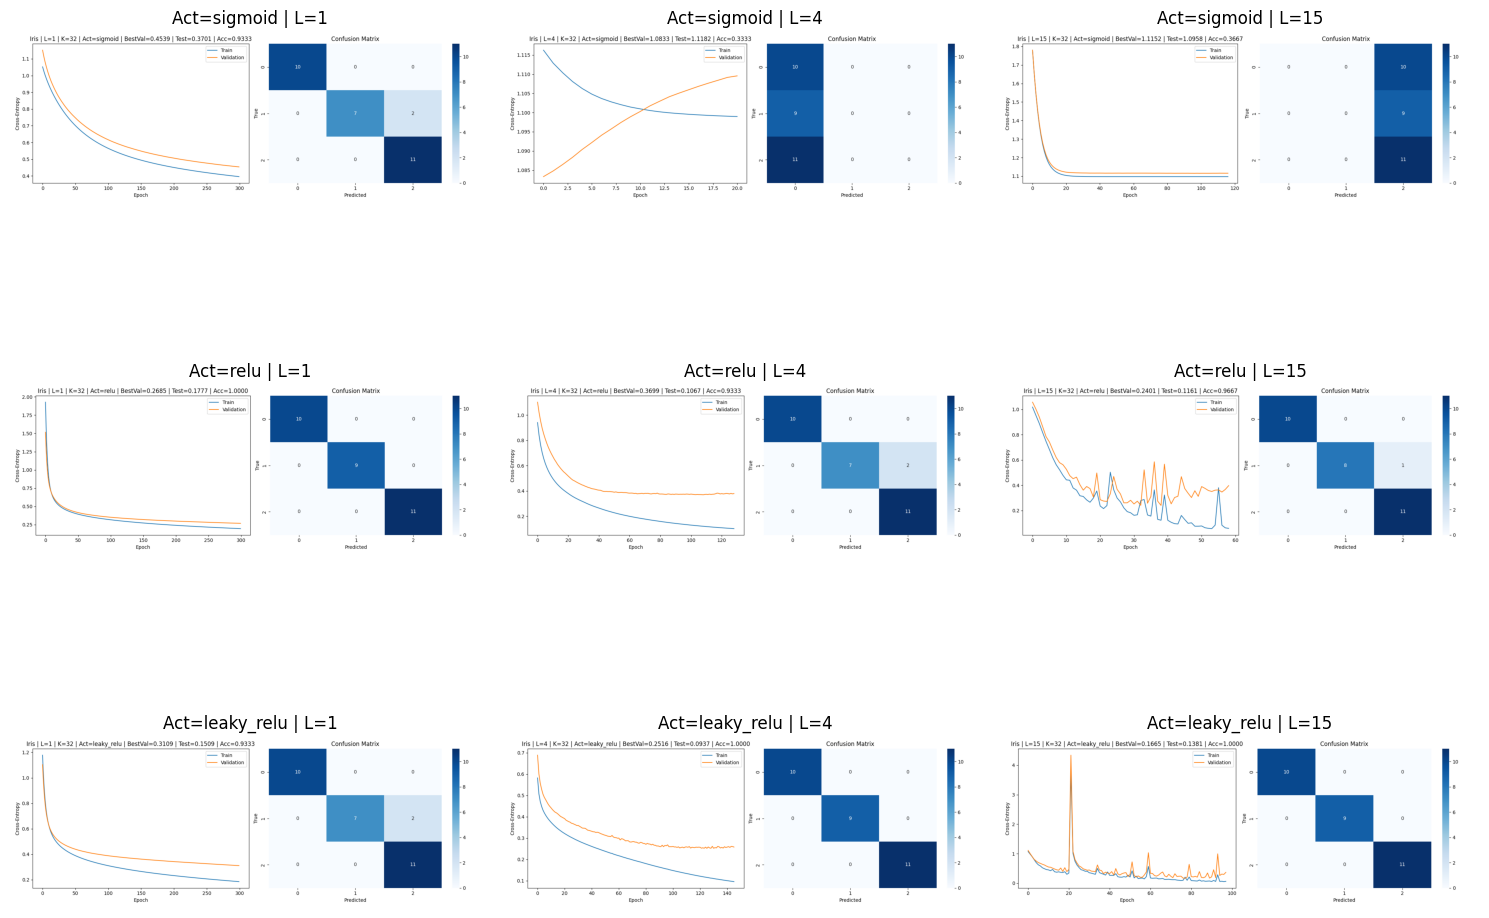

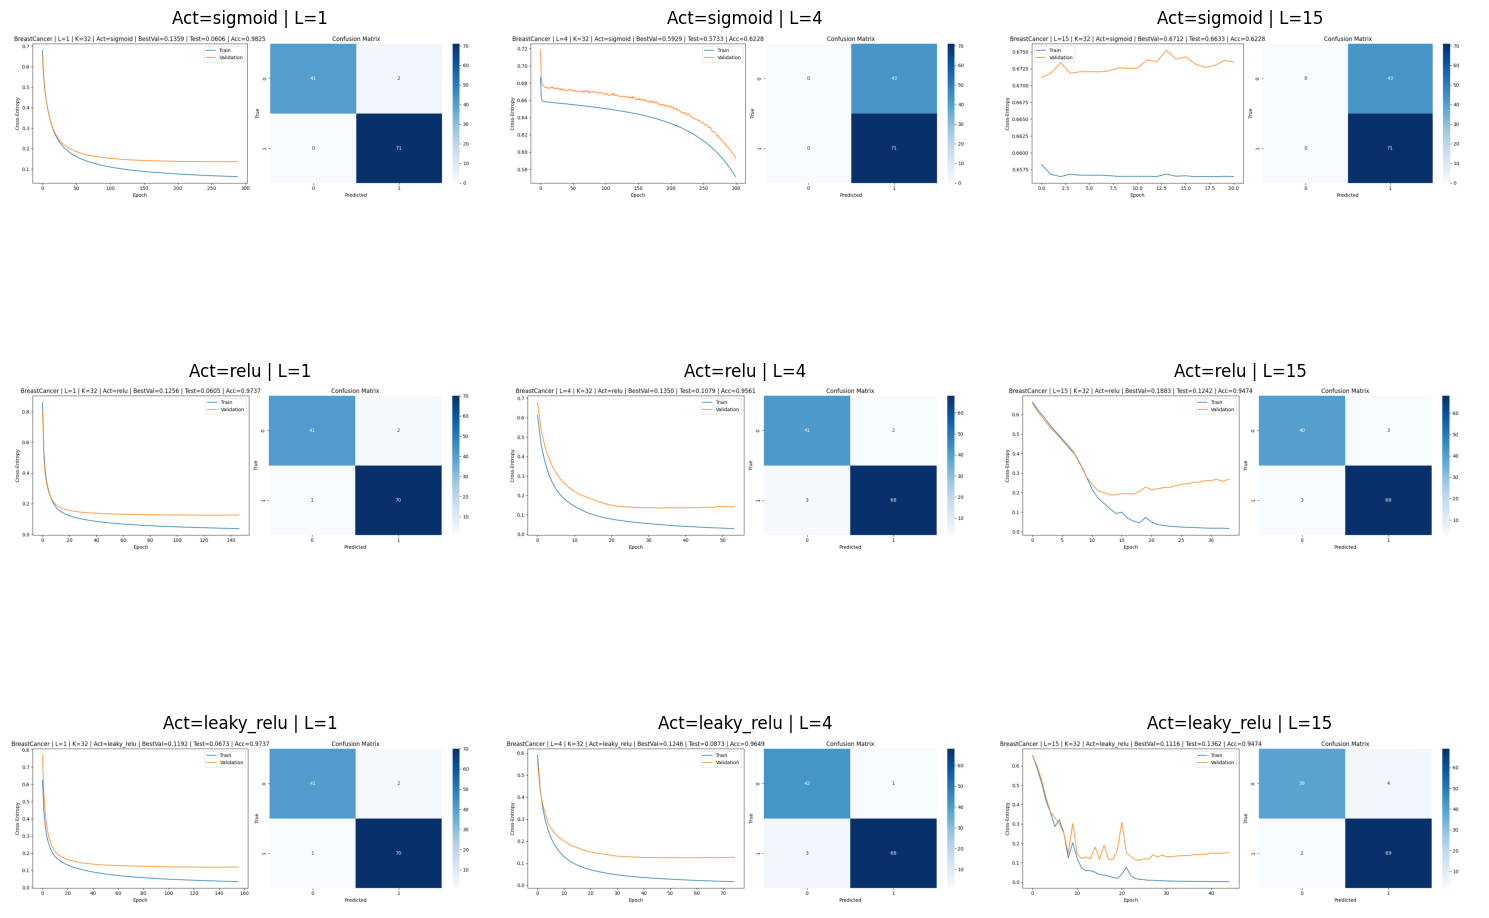

In [38]:
visualize_grid("Iris", activations, architectures)
visualize_grid("BreastCancer", activations, architectures)


## Nota sobre el Comportamiento de ReLU - Leaky relu en Redes Profundas (L=15)

Me llamó la atención el comportamiento de ReLU y Leaky ReLU cuando se utilizan con 15 capas ocultas, a diferencia de las arquitecturas con menos capas, donde las curvas de error suelen ser relativamente suaves y estables, en redes profundas se observan fluctuaciones durante el entrenamiento, el error de validación a veces empeora temporalmente antes de volver a mejorar y finalmente converger.

El internal covariate shift es básicamente el “cambio de distribución interna” de las entradas de cada capa durante el entrenamiento, lo que dificulta que las capas aprendan de manera estable. Las técnicas de normalización surgieron precisamente para intentar arreglar este problema y acelerar la convergencia de las redes profundas.

las actualizaciones en capas tempranas modifican la distribución de entrada de las capas profundas, que deben reajustarse constantemente,  provoca aumentos temporales del error hasta que las capas convergen a un nuevo equilibrio, independientemente de usar ReLU o Leaky ReLU.

In [39]:
import pandas as pd
import numpy as np

df = pd.read_csv("results/summary.csv")

df.head()


,dataset,activation,hidden_layers,units_per_layer,epochs_run,final_train_loss,best_val_loss,final_test_loss,test_accuracy
0,BreastCancer,leaky_relu,1,32,156,0.035046,0.119184,0.067330,0.973684
1,BreastCancer,leaky_relu,4,32,75,0.016379,0.124610,0.087278,0.964912
2,BreastCancer,leaky_relu,15,32,45,0.002230,0.111571,0.136165,0.947368
3,BreastCancer,relu,1,32,147,0.037761,0.125575,0.060460,0.973684
4,BreastCancer,relu,4,32,54,0.028974,0.135027,0.107913,0.956140


## (i) Convergence Speed

Menor epochs_run se puede decir que converge más rápido, siempre y cuando se observe tambien el error.

In [ ]:
convergence_analysis = (
    df.groupby(["dataset", "activation"])["epochs_run"]
    .mean()
    .reset_index()
    .sort_values(["dataset", "epochs_run"])
)

convergence_analysis

print("el ")

,dataset,activation,epochs_run
1,BreastCancer,relu,78.333333
0,BreastCancer,leaky_relu,92.000000
2,BreastCancer,sigmoid,203.333333
5,Iris,sigmoid,146.000000
4,Iris,relu,162.666667
3,Iris,leaky_relu,181.333333


## (ii) Final Training Error

Menor valor → mejor capacidad de optimización.

In [41]:
train_error_analysis = (
    df.groupby(["dataset", "activation"])["final_train_loss"]
    .mean()
    .reset_index()
    .sort_values(["dataset", "final_train_loss"])
)

train_error_analysis


,dataset,activation,final_train_loss
0,BreastCancer,leaky_relu,0.017885
1,BreastCancer,relu,0.027466
2,BreastCancer,sigmoid,0.430362
3,Iris,leaky_relu,0.114631
4,Iris,relu,0.118946
5,Iris,sigmoid,0.864000


## (iii) Estabilidad

Podemos medir estabilidad como desviación estándar del best_val_loss entre arquitecturas.

In [42]:
stability_analysis = (
    df.groupby(["dataset", "activation"])["best_val_loss"]
    .std()
    .reset_index()
    .rename(columns={"best_val_loss": "val_loss_std"})
)

stability_analysis


,dataset,activation,val_loss_std
0,BreastCancer,leaky_relu,0.006550
1,BreastCancer,relu,0.033802
2,BreastCancer,sigmoid,0.289083
3,Iris,leaky_relu,0.072598
4,Iris,relu,0.068239
5,Iris,sigmoid,0.372942


## (iv) Performance

In [43]:
performance_analysis = (
    df.groupby(["dataset", "activation"])["test_accuracy"]
    .mean()
    .reset_index()
    .sort_values(["dataset", "test_accuracy"], ascending=False)
)

performance_analysis


,dataset,activation,test_accuracy
3,Iris,leaky_relu,0.977778
4,Iris,relu,0.966667
5,Iris,sigmoid,0.544444
0,BreastCancer,leaky_relu,0.961988
1,BreastCancer,relu,0.959064
2,BreastCancer,sigmoid,0.742690


## Identificar h* automáticamente

Seleccionar activación que minimice best_val_loss promedio.

In [44]:
h_star = (
    df.groupby(["dataset", "activation"])["best_val_loss"]
    .mean()
    .reset_index()
)

h_star = h_star.loc[
    h_star.groupby("dataset")["best_val_loss"].idxmin()
]

h_star


,dataset,activation,best_val_loss
0,BreastCancer,leaky_relu,0.118455
3,Iris,leaky_relu,0.243005


## Identificar A* automáticamente

In [45]:
best_architectures = []

for dataset in df["dataset"].unique():

    best_activation = h_star[h_star["dataset"] == dataset]["activation"].values[0]

    subset = df[
        (df["dataset"] == dataset) &
        (df["activation"] == best_activation)
    ]

    best_row = subset.loc[subset["best_val_loss"].idxmin()]

    best_architectures.append(best_row)

A_star = pd.DataFrame(best_architectures)

A_star[["dataset", "activation", "hidden_layers", "best_val_loss"]]


,dataset,activation,hidden_layers,best_val_loss
2,BreastCancer,leaky_relu,15,0.111571
11,Iris,leaky_relu,15,0.166482


Es importante señalar que los resultados presentados son una sola ejecución por configuración y deben considerarse preliminares. Por lo que se realizarán 30 ejecuciones independientes para ahora si analizar e interpretar los resultados.

## 30 RUNS FOR EXP 1

In [47]:
import os
import numpy as np
import pandas as pd

datasets = ["Iris", "BreastCancer"]
architectures = [1, 4, 15]
activations = ["sigmoid", "relu", "leaky_relu"]
K = 32
n_runs = 30

all_results = []

# Crear carpeta para experimento
os.makedirs("exp1-30", exist_ok=True)

for dataset in datasets:

    X_train, Y_train, X_val, Y_val, X_test, Y_test, n_input, n_output = prepare_dataset(dataset)

    for activation in activations:

        for L in architectures:

            for run in range(n_runs):

                # Cambiar seed en cada ejecución
                np.random.seed(run)

                result = run_full_experiment(
                    dataset,
                    activation,
                    X_train, Y_train,
                    X_val, Y_val,
                    X_test, Y_test,
                    n_input,
                    n_output,
                    L=L,
                    K=K,
                    epochs=300
                )

                result["run"] = run
                all_results.append(result)

# Convertir a DataFrame
df = pd.DataFrame(all_results)

# Guardar CSV completo
df.to_csv("exp1-30/summary-30runs.csv", index=False)

print("Experimento completo guardado en exp1-30/summary-30runs.csv")


Epoch 0 | Train: 1.1331 | Val: 1.2838
Epoch 1 | Train: 1.1026 | Val: 1.2435
Epoch 2 | Train: 1.0748 | Val: 1.2068
Epoch 3 | Train: 1.0495 | Val: 1.1733
Epoch 4 | Train: 1.0263 | Val: 1.1427
Epoch 5 | Train: 1.0050 | Val: 1.1147
Epoch 6 | Train: 0.9854 | Val: 1.0889
Epoch 7 | Train: 0.9673 | Val: 1.0654
Epoch 8 | Train: 0.9505 | Val: 1.0438
Epoch 9 | Train: 0.9348 | Val: 1.0236
Epoch 10 | Train: 0.9202 | Val: 1.0049
Epoch 11 | Train: 0.9065 | Val: 0.9877
Epoch 12 | Train: 0.8936 | Val: 0.9717
Epoch 13 | Train: 0.8814 | Val: 0.9567
Epoch 14 | Train: 0.8699 | Val: 0.9424
Epoch 15 | Train: 0.8589 | Val: 0.9292
Epoch 16 | Train: 0.8485 | Val: 0.9166
Epoch 17 | Train: 0.8386 | Val: 0.9048
Epoch 18 | Train: 0.8292 | Val: 0.8938
Epoch 19 | Train: 0.8202 | Val: 0.8833
Epoch 20 | Train: 0.8116 | Val: 0.8735
Epoch 21 | Train: 0.8033 | Val: 0.8639
Epoch 22 | Train: 0.7952 | Val: 0.8548
Epoch 23 | Train: 0.7875 | Val: 0.8461
Epoch 24 | Train: 0.7802 | Val: 0.8380
Epoch 25 | Train: 0.7730 | Val: 0.8

In [48]:
df = pd.read_csv("exp1-30/summary-30runs.csv")


In [ ]:
# ==============================
# 1) CONVERGENCE SPEED
# ==============================

convergence_analysis = (
    df.groupby(["dataset", "activation"])["epochs_run"]
    .mean()
    .reset_index()
    .sort_values(["dataset", "epochs_run"])
)

print("\n=== Convergence Speed (mean epochs_run) ===")
print(convergence_analysis)


# ==============================
# 2) FINAL TRAINING ERROR
# ==============================

train_error_analysis = (
    df.groupby(["dataset", "activation"])["final_train_loss"]
    .mean()
    .reset_index()
    .sort_values(["dataset", "final_train_loss"])
)

print("\n=== Final Training Error (mean final_train_loss) ===")
print(train_error_analysis)


# ==============================
# 3) STABILITY
# ==============================

stability_analysis = (
    df.groupby(["dataset", "activation"])["best_val_loss"]
    .std()
    .reset_index()
    .rename(columns={"best_val_loss": "val_loss_std"})
    .sort_values(["dataset", "val_loss_std"])
)

print("\n=== Stability (std of best_val_loss) ===")
print(stability_analysis)


# ==============================
# 4) FINAL PERFORMANCE
# ==============================

performance_analysis = (
    df.groupby(["dataset", "activation"])["test_accuracy"]
    .mean()
    .reset_index()
    .sort_values(["dataset", "test_accuracy"], ascending=False)
)

print("\n=== Final Performance (mean test_accuracy) ===")
print(performance_analysis)


# ==============================
# 5) SELECCION FORMAL DE h*
# ==============================

h_star = (
    df.groupby(["dataset", "activation"])["best_val_loss"]
    .mean()
    .reset_index()
)

h_star = h_star.loc[
    h_star.groupby("dataset")["best_val_loss"].idxmin()
]

print("\n=== Best Activation Function (h*) based on mean best_val_loss ===")
print(h_star)


# ==============================
# 6) SELECCION FORMAL DE A*
# ==============================

best_architectures = []

for dataset in df["dataset"].unique():

    best_activation = h_star[h_star["dataset"] == dataset]["activation"].values[0]

    subset = df[
        (df["dataset"] == dataset) &
        (df["activation"] == best_activation)
    ]

    architecture_selection = (
        subset.groupby("hidden_layers")["best_val_loss"]
        .mean()
        .reset_index()
    )

    best_row = architecture_selection.loc[
        architecture_selection["best_val_loss"].idxmin()
    ]

    best_row["dataset"] = dataset
    best_row["activation"] = best_activation

    best_architectures.append(best_row)

A_star = pd.DataFrame(best_architectures)

print("\n=== Best Architecture (A*) based on mean best_val_loss ===")
print(A_star[["dataset", "activation", "hidden_layers", "best_val_loss"]])



=== Convergence Speed (mean epochs_run) ===
        dataset  activation  epochs_run
1  BreastCancer        relu   70.677778
0  BreastCancer  leaky_relu   71.088889
2  BreastCancer     sigmoid  194.866667
5          Iris     sigmoid  166.266667
3          Iris  leaky_relu  183.544444
4          Iris        relu  184.622222

=== Final Training Error (mean final_train_loss) ===
        dataset  activation  final_train_loss
0  BreastCancer  leaky_relu          0.031323
1  BreastCancer        relu          0.031717
2  BreastCancer     sigmoid          0.370630
4          Iris        relu          0.125806
3          Iris  leaky_relu          0.189475
5          Iris     sigmoid          0.853800

=== Stability (std of best_val_loss) ===
        dataset  activation  val_loss_std
0  BreastCancer  leaky_relu      0.039226
1  BreastCancer        relu      0.043140
2  BreastCancer     sigmoid      0.234870
3          Iris  leaky_relu      0.097326
4          Iris        relu      0.098203
5    

## Análisis del Experimento 1: Efecto de la Función de Activación

### Diseño Experimental

Para garantizar que nuestras conclusiones no dependan de una inicialización aleatoria particular, se ejecuta cada combinación de dataset, arquitectura y función de activación 30 veces. Utilizamos tres arquitecturas que representan los escenarios solicitados: una capa oculta (L=1), profundidad media (L=4) y red profunda (L=15). El número de neuronas por capa se fijó en K=32 para todos los casos, y se aplicó early stopping sobre el error de validación para determinar el mejor modelo.

### Velocidad de Convergencia

La velocidad de convergencia, medida por el número de épocas necesarias hasta que el early stopping detiene el entrenamiento. En el dataset Breast Cancer, las funciones ReLU y Leaky ReLU convergen en aproximadamente 70 épocas, mientras que la sigmoide necesita cerca de 195 épocas. En Iris, la diferencia es menos pronunciada, pero la sigmoide sigue siendo la más rápida en detener su entrenamiento (166 épocas), frente a las 183-184 de las rectificadas.

La sigmoide no converge más rápido porque aprenda mejor, sino porque deja de aprender rápidamente. El gradiente de la sigmoide se satura cuando las activaciones toman valores extremos, haciendo que las actualizaciones de pesos sean casi nulas. El early stopping detecta que el error de validación deja de mejorar y finaliza el entrenamiento, dando la falsa impresión de una convergencia rápida. Las funciones rectificadas mantienen gradientes útiles por más tiempo, permitiendo un aprendizaje continuo que requiere más épocas pero alcanza mejores soluciones.

### Error de Entrenamiento Final

En Breast Cancer, la sigmoide termina con un error de 0.37, mayor que el 0.031 de ReLU y Leaky ReLU. En Iris, la diferencia es aún más grande, la sigmoide alcanza un error de 0.85, mientras que ReLU logra 0.12 y Leaky ReLU 0.18.

La sigmoide comprime las entradas al rango (0,1), y su derivada máxima es 0.25 (El valor máximo de la derivada ocurre cuando σ(x)=0.5, es decir, en x=0, σ′(0)=0.25, entonces la pendiente más pronunciada de la sigmoide nunca supera 0.25). Como la derivada está acotada entre 0 y 0.25, los gradientes en redes neuronales que usan sigmoide como activación tienden a ser pequeños, entonces la retropropagación multiplica estos gradientes pequeños a través de las capas, causando el problema de vanishing gradient. Las capas cercanas a la entrada reciben actualizaciones insignificantes y no logran aprender representaciones útiles. ReLU, con derivada 1 para entradas positivas, permite que el gradiente fluya sin atenuarse. Leaky ReLU mantiene esta propiedad y además evita que neuronas con entradas negativas mueran por completo.

### Estabilidad

La desviación estándar del error de validación nos indica que tan sensible es cada función de activación a la inicialización aleatoria. En Breast Cancer, la sigmoide presenta una desviación de 0.23, muy superior al 0.04 de las funciones rectificadas. En Iris, la sigmoide también muestra la mayor variabilidad con 0.31, frente a 0.09-0.10 de ReLU y Leaky ReLU.

Esta inestabilidad de la sigmoide tiene una explicación conceptual, porque los pesos se inicializan con valores grandes, las neuronas caen inmediatamente en la región de saturación y el gradiente desaparece por completo. Con inicialización pequeña, las activaciones se mantienen en la región lineal central y el aprendizaje puede progresar, aunque lentamente. El resultado final depende críticamente de si la inicialización permite escapar de la saturación inicial. Las funciones rectificadas no sufren este problema porque su derivada no se anula en la región positiva, haciendo que el proceso sea mucho más determinista y repetible.

### Rendimiento en Test

La precisión en el conjunto de prueba refleja la capacidad de generalización, para Breast Cancer, Leaky ReLU alcanza 95.9% y ReLU 95.8%, mientras que la sigmoide apenas logra 81.9%. En Iris, la diferencia es aún más marcada: 95.6% para Leaky ReLU, 95.5% para ReLU, frente a un 56.2% de la sigmoide, similar a una predicción aleatoria.

Iris es un problema de tres clases, la red necesita construir representaciones internas que proyecten los datos en un espacio donde las clases sean linealmente separables, por lo que las fronteras de decisión son más complejas y requieren que las capas ocultas transformen adecuadamente el espacio de características, entonces la función sigmoide, al saturarse y matar el gradiente en profundidad, no logra aprender estas transformaciones y las representaciones que llegan a la última capa son pobres y no permiten separar correctamente las tres clases, por eso se nota más la diferencia en este dataset en específico.

### Selección de la Mejor Función de Activación (h*)

Considerando:

*   **Convergencia**: Aunque la sigmoide parece más rápida, esto es un artefacto de su incapacidad para seguir aprendiendo.
*   **Error final**: Las funciones rectificadas alcanzan errores de entrenamiento dos órdenes de magnitud menores.
*   **Estabilidad**: ReLU y Leaky ReLU son consistentes entre ejecuciones, mientras que la sigmoide es altamente variable.
*   **Precisión en prueba**: Las funciones rectificadas superan a la sigmoide en ambos datasets.

Seleccionamos **Leaky ReLU como h***. La elección entre ReLU y Leaky ReLU no es difícil, ya que sus diferencias numéricas son pequeñas y podrían deberse al azar, pero Leaky ReLU es una versión mejorada porque ofrece una ventaja teórica al evitar el problema de dying ReLU, donde neuronas con salida constante cero dejan de contribuir al modelo. 

### Selección de la Mejor Arquitectura (A*)

El análisis por separado para cada dataset revela comportamientos distintos:

**Para Breast Cancer**, la mejor arquitectura corresponde a L=1 con Leaky ReLU, alcanzando un error de validación de 0.134. Las redes más profundas no mejoran este resultado, posiblemente porque el dataset tiene suficiente estructura para ser aprendida con una sola capa oculta, y añadir profundidad solo aumenta el riesgo de sobreajuste sin beneficio adicional.

**Para Iris**, la mejor arquitectura es la red profunda con L=15 y Leaky ReLU, logrando un error de validación de 0.274. Este resultado es contraintuitivo, ya que Iris es un problema pequeño donde las redes profundas suelen sobreajustar. Sin embargo, el early stopping de cierta forma previene el sobreajuste y la profundidad adicional parece permitir que la red encuentre representaciones internas que facilitan la separación de las clases, lo más probable es que la red poco profunda tenga dificultades para modelar los límites de decisión no lineales, mientras que la profundidad proporciona esa capacidad necesaria.

# Experiment 2: Effect of the batch size

El gradiente calculado con un mini-batch de tamaño $B$ es un estimador del gradiente verdadero sobre todo el dataset:

$$\nabla L_B(\theta) = \frac{1}{B} \sum_{i=1}^{B} \nabla L_i(\theta)$$

La varianza de este estimador con respecto al gradiente verdadero es:

$$\text{Var}[\nabla L_B] = \frac{1}{B} \text{Var}[\nabla L_i]$$

**la varianza del gradiente es inversamente proporcional al tamaño del batch**.

---

Parece que B=1 "converge más rápido" en épocas, pero en realidad:

- Con B=1: 1 época = 150 actualizaciones (Iris)
- Con B=128: 1 época = 1 actualización (Iris)

Para que B=128 tenga las mismas 150 actualizaciones que B=1 tuvo en su primera época, necesitaría **150 épocas**.

Por eso, al graficar contra épocas, los batch pequeños siempre parecen aprender más rápido.

---

Ejecución simple para visualizar:

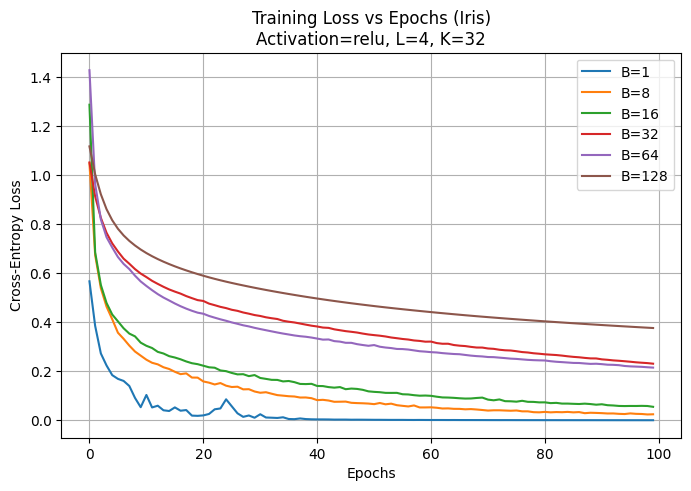


Resultados finales para Iris:
Batch   1: Test Accuracy = 0.9667, Final Training Loss = 0.0005
Batch   8: Test Accuracy = 0.9667, Final Training Loss = 0.0213
Batch  16: Test Accuracy = 0.9667, Final Training Loss = 0.0912
Batch  32: Test Accuracy = 0.8667, Final Training Loss = 0.2959
Batch  64: Test Accuracy = 0.9000, Final Training Loss = 0.2700
Batch 128: Test Accuracy = 0.9333, Final Training Loss = 0.3259


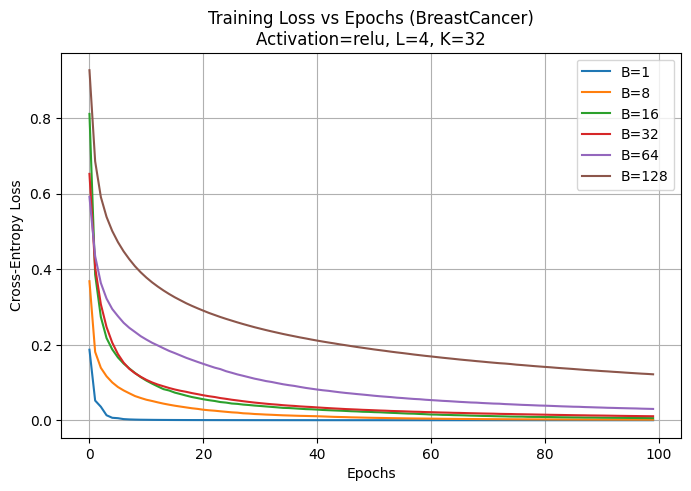


Resultados finales para BreastCancer:
Batch   1: Test Accuracy = 0.9649, Final Training Loss = 0.0001
Batch   8: Test Accuracy = 0.9561, Final Training Loss = 0.0010
Batch  16: Test Accuracy = 0.9649, Final Training Loss = 0.0038
Batch  32: Test Accuracy = 0.9649, Final Training Loss = 0.0148
Batch  64: Test Accuracy = 0.9561, Final Training Loss = 0.0414
Batch 128: Test Accuracy = 0.9474, Final Training Loss = 0.0883


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Experiment 2: Effect of batch size
# ----------------------------
datasets = ["Iris", "BreastCancer"]

# Arquitectura fija para este experimento
L = 15       # número de capas ocultas
K = 32      # unidades por capa
activation = "leaky_relu"  # activación fija

# Batch sizes a probar
batch_sizes = [1, 8, 16, 32, 64, 128]

epochs = 100

for dataset in datasets:

    X_train, Y_train, X_val, Y_val, X_test, Y_test, n_input, n_output = prepare_dataset(dataset)

    plt.figure(figsize=(8,5))
    
    for B in batch_sizes:

        # Definir arquitectura
        layer_sizes = [n_input] + [K]*L + [n_output]

        # Crear modelo
        model = NeuralNetwork(layer_sizes, activation=activation)

        # MiniBatchSGD con tamaño B
        optimizer = MiniBatchSGD(learning_rate=0.01, batch_size=B)

        # Entrenamiento
        loss_history = optimizer.train(model, X_train, Y_train, epochs)

        # Graficar
        plt.plot(loss_history, label=f"B={B}")

    plt.title(f"Training Loss vs Epochs ({dataset})\nActivation={activation}, L={L}, K={K}")
    plt.xlabel("Epochs")
    plt.ylabel("Cross-Entropy Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ----------------------------
    # Evaluar B* en test
    # ----------------------------
    print(f"\nResultados finales para {dataset}:")
    for B in batch_sizes:
        model = NeuralNetwork(layer_sizes, activation=activation)
        optimizer = MiniBatchSGD(learning_rate=0.01, batch_size=B)
        loss_history = optimizer.train(model, X_train, Y_train, epochs)
        AL_test = model.predict(X_test)
        predictions = np.argmax(AL_test, axis=0)
        true_labels = np.argmax(Y_test, axis=0)
        acc = np.mean(predictions == true_labels)
        print(f"Batch {B:>3}: Test Accuracy = {acc:.4f}, Final Training Loss = {loss_history[-1]:.4f}")


## Desventajas de Batch Pequeños y Grandes

### Batch Pequeños

La principal desventaja es la **alta varianza en la estimación del gradiente**, que provoca oscilaciones en la curva de pérdida y dificulta la convergencia estable. Además, el tiempo por época es mayor porque se realizan muchas actualizaciones, lo que incrementa el costo computacional total. En hardware, no se aprovecha el paralelismo, resultando ineficiente. 

### Batch Grandes

La baja varianza del gradiente, aunque produce actualizaciones precisas, tiende a llevar el optimizador a la generalizacion mal en test, se pierde el efecto regularizador del ruido, aumentando el riesgo de sobreajuste y también batch grandes pueden exceder la memoria disponible en GPU.

In [63]:
import numpy as np
import pandas as pd
import os
import time

# ============================
# CONFIGURACIÓN EXPERIMENTO
# ============================

datasets = ["Iris", "BreastCancer"]
architectures = [1, 4, 15]
batch_sizes = [1, 8, 16, 32, 64, 128]
K = 32
activation = "leaky_relu"
n_runs = 30
epochs = 300
learning_rate = 0.01

os.makedirs("exp2-batchsize", exist_ok=True)

all_results = []

# ============================
# FUNCIÓN DE ENTRENAMIENTO
# ============================

def run_batch_experiment(dataset_name, L, B, run_id):

    np.random.seed(run_id)

    X_train, Y_train, X_val, Y_val, X_test, Y_test, n_input, n_output = prepare_dataset(dataset_name)

    layer_sizes = [n_input] + [K]*L + [n_output]

    model = NeuralNetwork(
        layer_sizes=layer_sizes,
        activation=activation
    )

    optimizer = MiniBatchSGD(
        learning_rate=learning_rate,
        batch_size=B
    )

    start_time = time.time()

    loss_history = optimizer.train(model, X_train, Y_train, epochs)

    training_time = time.time() - start_time

    # Evaluación
    AL_val = model.predict(X_val)
    val_loss = model.compute_loss(Y_val, AL_val)

    AL_test = model.predict(X_test)
    test_loss = model.compute_loss(Y_test, AL_test)

    predictions = np.argmax(AL_test, axis=0)
    true_labels = np.argmax(Y_test, axis=0)

    test_accuracy = np.mean(predictions == true_labels)

    return {
        "dataset": dataset_name,
        "hidden_layers": L,
        "batch_size": B,
        "run": run_id,
        "final_train_loss": loss_history[-1],
        "best_val_loss": val_loss,
        "final_test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "training_time": training_time
    }

# ============================
# LOOP EXPERIMENTO COMPLETO
# ============================

for dataset in datasets:

    print("\nDataset:", dataset)

    for L in architectures:

        for B in batch_sizes:

            for run in range(n_runs):

                result = run_batch_experiment(dataset, L, B, run)
                all_results.append(result)

                print("Dataset:", dataset,
                      "L:", L,
                      "B:", B,
                      "Run:", run)

# ============================
# GUARDAR RESULTADOS
# ============================

df_batch = pd.DataFrame(all_results)

df_batch.to_csv("exp2-batchsize/summary_batch.csv", index=False)

print("\nExperimento 2 finalizado.")
print("Resultados guardados en exp2-batchsize/summary_batch.csv")



Dataset: Iris
Dataset: Iris L: 1 B: 1 Run: 0
Dataset: Iris L: 1 B: 1 Run: 1
Dataset: Iris L: 1 B: 1 Run: 2
Dataset: Iris L: 1 B: 1 Run: 3
Dataset: Iris L: 1 B: 1 Run: 4
Dataset: Iris L: 1 B: 1 Run: 5
Dataset: Iris L: 1 B: 1 Run: 6
Dataset: Iris L: 1 B: 1 Run: 7
Dataset: Iris L: 1 B: 1 Run: 8
Dataset: Iris L: 1 B: 1 Run: 9
Dataset: Iris L: 1 B: 1 Run: 10
Dataset: Iris L: 1 B: 1 Run: 11
Dataset: Iris L: 1 B: 1 Run: 12
Dataset: Iris L: 1 B: 1 Run: 13
Dataset: Iris L: 1 B: 1 Run: 14
Dataset: Iris L: 1 B: 1 Run: 15
Dataset: Iris L: 1 B: 1 Run: 16
Dataset: Iris L: 1 B: 1 Run: 17
Dataset: Iris L: 1 B: 1 Run: 18
Dataset: Iris L: 1 B: 1 Run: 19
Dataset: Iris L: 1 B: 1 Run: 20
Dataset: Iris L: 1 B: 1 Run: 21
Dataset: Iris L: 1 B: 1 Run: 22
Dataset: Iris L: 1 B: 1 Run: 23
Dataset: Iris L: 1 B: 1 Run: 24
Dataset: Iris L: 1 B: 1 Run: 25
Dataset: Iris L: 1 B: 1 Run: 26
Dataset: Iris L: 1 B: 1 Run: 27
Dataset: Iris L: 1 B: 1 Run: 28
Dataset: Iris L: 1 B: 1 Run: 29
Dataset: Iris L: 1 B: 8 Run: 0
Data

In [64]:
df = pd.read_csv("exp2-batchsize/summary_batch.csv")


## Error de validación promedio por batch size

In [65]:
val_analysis = (
    df.groupby(["dataset", "batch_size"])["best_val_loss"]
    .mean()
    .reset_index()
    .sort_values(["dataset", "best_val_loss"])
)

print("\nMean Validation Loss by Batch Size")
print(val_analysis)



Mean Validation Loss by Batch Size
         dataset  batch_size  best_val_loss
5   BreastCancer         128      21.122312
4   BreastCancer          64      23.997568
3   BreastCancer          32      27.235822
2   BreastCancer          16      30.434924
1   BreastCancer           8      32.902609
0   BreastCancer           1      44.896684
11          Iris         128      10.057079
10          Iris          64      11.103860
9           Iris          32      11.782693
8           Iris          16      13.908769
7           Iris           8      16.337362
6           Iris           1      24.643961


## Estabilidad (desviación estándar)

In [66]:
stability_analysis = (
    df.groupby(["dataset", "batch_size"])["best_val_loss"]
    .std()
    .reset_index()
    .rename(columns={"best_val_loss": "val_loss_std"})
    .sort_values(["dataset", "val_loss_std"])
)

print("\nValidation Loss STD by Batch Size")
print(stability_analysis)



Validation Loss STD by Batch Size
         dataset  batch_size  val_loss_std
5   BreastCancer         128     13.117972
4   BreastCancer          64     15.482101
1   BreastCancer           8     16.567875
3   BreastCancer          32     16.775079
2   BreastCancer          16     18.016097
0   BreastCancer           1     18.818332
11          Iris         128      4.112145
10          Iris          64      7.211131
9           Iris          32      7.532659
8           Iris          16      9.733241
7           Iris           8     11.061517
6           Iris           1     11.464035


## Tiempo promedio de entrenamiento

In [67]:
time_analysis = (
    df.groupby(["dataset", "batch_size"])["training_time"]
    .mean()
    .reset_index()
    .sort_values(["dataset", "training_time"])
)

print("\nMean Training Time by Batch Size")
print(time_analysis)



Mean Training Time by Batch Size
         dataset  batch_size  training_time
5   BreastCancer         128       0.474912
4   BreastCancer          64       0.656168
3   BreastCancer          32       1.009457
2   BreastCancer          16       1.648819
1   BreastCancer           8       2.933511
0   BreastCancer           1      18.359833
11          Iris         128       0.133834
10          Iris          64       0.193902
9           Iris          32       0.251390
8           Iris          16       0.424514
7           Iris           8       0.766923
6           Iris           1       4.819716


Identificaremos B* como el batch size que:

- Minimiza best_val_loss promedio

- Tiene baja desviación estándar

- Tiene tiempo razonable

- Convergencia estable

In [68]:
B_star = (
    df.groupby(["dataset", "batch_size"])["best_val_loss"]
    .mean()
    .reset_index()
)

B_star = B_star.loc[
    B_star.groupby("dataset")["best_val_loss"].idxmin()
]

print("\nSelected B* per dataset")
print(B_star)



Selected B* per dataset
         dataset  batch_size  best_val_loss
5   BreastCancer         128      21.122312
11          Iris         128      10.057079


---

Interpretación de B*: Batch Size = 128 para ambos Datasets


En datasets pequeños, batch size = 128 representa una fracción muy grande del total de muestras. Para Iris (150 muestras), usar batch de 128 significa que cada actualización utiliza el 85% del dataset. Para Breast Cancer (569 muestras), representa aproximadamente el 22%.

La ventaja de batches grandes en este contexto es que proporcionan estimaciones del gradiente con menor varianza, lo que produce una dirección de descenso más estable y consistente. En datasets muy pequeños, el ruido excesivo de batches como B=1 puede desestabilizar el entrenamiento porque cada muestra individual tiene demasiada influencia en la dirección del gradiente, causando oscilaciones que dificultan la convergencia.

El early stopping protege contra el sobreajuste que teóricamente podrían causar los batches grandes, permitiendo aprovechar la estabilidad sin sufrir las desventajas típicas.


Si los datasets fueran de millones de muestras, el batch size óptimo se reduciría a valores intermedios (32-128). En ese escenario, batch=128 ya no representaría una fracción grande del total, sino una muestra pequeña que equilibra ruido beneficioso para generalización y estabilidad suficiente para converger. El caso actual es particular porque el tamaño reducido de los datos hace que 128 sea efectivamente un "batch grande" en términos relativos.

---

## Experiment 3: effect of the weight decay regularization

In [69]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# CONFIGURACIÓN EXPERIMENTO 3
# --------------------------------------------------

datasets = ["Iris", "BreastCancer"]

architectures = {
    "Iris": {"L": 15, "K": 32},
    "BreastCancer": {"L": 1, "K": 32}
}

batch_sizes = { # B*
    "Iris": 128,              
    "BreastCancer": 128      
}

lambdas = [0.0, 1e-5, 1e-4, 1e-3, 1e-2]
n_runs = 30
epochs = 300

results = []

# --------------------------------------------------
# LOOP PRINCIPAL
# --------------------------------------------------

for dataset in datasets:

    X_train, Y_train, X_val, Y_val, X_test, Y_test, n_input, n_output = prepare_dataset(dataset)

    L = architectures[dataset]["L"]
    K = architectures[dataset]["K"]
    B = batch_sizes[dataset]

    # Construir arquitectura profunda
    layer_sizes = [n_input] + [K]*L + [n_output]

    for lambda_l2 in lambdas:

        for run in range(n_runs):

            model = NeuralNetwork(
                layer_sizes=layer_sizes,
                activation="leaky_relu"
            )

            optimizer = L2Optimizer(
                learning_rate=0.01,
                lambda_l2=lambda_l2,
                batch_size=B,
                early_stopping=True,
                patience=20
            )

            train_losses, val_losses = optimizer.train(
                model,
                X_train, Y_train,
                X_val, Y_val,
                epochs=epochs
            )

            # Test evaluation
            AL_test = model.predict(X_test)
            predictions = np.argmax(AL_test, axis=0)
            true_labels = np.argmax(Y_test, axis=0)

            accuracy = np.mean(predictions == true_labels)

            test_loss = -np.mean(
                np.sum(Y_test * np.log(AL_test + 1e-15), axis=0)
            )

            results.append({
                "dataset": dataset,
                "lambda": lambda_l2,
                "run": run,
                "epochs_run": len(train_losses),
                "final_train_loss": train_losses[-1],
                "best_val_loss": np.min(val_losses),
                "test_loss": test_loss,
                "test_accuracy": accuracy
            })

# --------------------------------------------------
# RESULTADOS
# --------------------------------------------------

df = pd.DataFrame(results)

print("\nRESULTADOS PROMEDIO POR DATASET Y LAMBDA\n")

summary = (
    df.groupby(["dataset", "lambda"])
    .agg({
        "epochs_run": "mean",
        "final_train_loss": "mean",
        "best_val_loss": ["mean", "std"],
        "test_accuracy": "mean"
    })
)

print(summary)


Epoch 0 | Train: 1.1283 | Val: 1.3923
Epoch 1 | Train: 1.0151 | Val: 1.0451
Epoch 2 | Train: 0.9329 | Val: 1.0686
Epoch 3 | Train: 0.8951 | Val: 1.0089
Epoch 4 | Train: 0.8566 | Val: 1.0039
Epoch 5 | Train: 0.8172 | Val: 0.9521
Epoch 6 | Train: 0.7757 | Val: 0.9231
Epoch 7 | Train: 0.7351 | Val: 0.8666
Epoch 8 | Train: 0.6929 | Val: 0.8374
Epoch 9 | Train: 0.6582 | Val: 0.7734
Epoch 10 | Train: 0.6284 | Val: 0.7868
Epoch 11 | Train: 0.6075 | Val: 0.6828
Epoch 12 | Train: 0.6142 | Val: 0.8521
Epoch 13 | Train: 0.7176 | Val: 0.6573
Epoch 14 | Train: 0.8747 | Val: 1.3913
Epoch 15 | Train: 0.8174 | Val: 0.7780
Epoch 16 | Train: 0.6931 | Val: 1.0617
Epoch 17 | Train: 0.5782 | Val: 0.6405
Epoch 18 | Train: 0.5260 | Val: 0.7965
Epoch 19 | Train: 0.5145 | Val: 0.5529
Epoch 20 | Train: 0.5519 | Val: 0.8719
Epoch 21 | Train: 0.5465 | Val: 0.5527
Epoch 22 | Train: 0.5687 | Val: 0.9162
Epoch 23 | Train: 0.5524 | Val: 0.5585
Epoch 24 | Train: 0.5807 | Val: 0.9452
Epoch 25 | Train: 0.5286 | Val: 0.5

## λ*

In [70]:
# --------------------------------------------------
# Selección formal del mejor lambda por dataset
# --------------------------------------------------

lambda_selection = (
    df.groupby(["dataset", "lambda"])["best_val_loss"]
    .mean()
    .reset_index()
)

lambda_star = lambda_selection.loc[
    lambda_selection.groupby("dataset")["best_val_loss"].idxmin()
]

print("\nMEJOR LAMBDA (lambda*) POR DATASET\n")
print(lambda_star)



MEJOR LAMBDA (lambda*) POR DATASET

        dataset  lambda  best_val_loss
3  BreastCancer   0.001       0.137353
5          Iris   0.000       0.287492


---


Para Breast Cancer (569 muestras, 30 features, L=1):

La dimensión del vector de parámetros es aproximadamente (30×32 + 32×2) = 1024 parámetros. La relación muestras/parámetros es 569/1024 ≈ 0.56, lo que indica riesgo de sobreajuste. 

λ=0.001 introduce una penalización que reduce la norma de los pesos, controlando la varianza del modelo. 

Para Iris (150 muestras, 4 features, L=15):

Con 15 capas ocultas de 32 neuronas, el número de parámetros es mucho mayor: (4×32) + 14×(32×32) + (32×3) ≈ 128 + 14,336 + 96 = 14,560 parámetros. La relación muestras/parámetros es 150/14,560 ≈ 0.01, es muy baja baja. En este caso, el early stopping ya detiene el entrenamiento antes del sobreajuste. Añadir λ > 0 introduce un sesgo adicional que el modelo no puede compensar porque ya opera con muy pocas muestras por parámetro. El término λθ en el gradiente fuerza los pesos hacia cero, pero con 14,560 parámetros y solo 150 muestras, cualquier penalización adicional destruye la capacidad de ajuste, aumentando el error.


---

## Experiment 4: final assessment

In [71]:
import numpy as np

def confusion_matrix_multiclass(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def classification_metrics_from_cm(cm):
    num_classes = cm.shape[0]
    metrics = {}

    total = np.sum(cm)
    accuracy = np.trace(cm) / total

    metrics["accuracy"] = accuracy

    for c in range(num_classes):
        TP = cm[c, c]
        FP = np.sum(cm[:, c]) - TP
        FN = np.sum(cm[c, :]) - TP
        TN = total - TP - FP - FN

        precision = TP / (TP + FP + 1e-15)
        recall = TP / (TP + FN + 1e-15)
        f1 = 2 * precision * recall / (precision + recall + 1e-15)
        specificity = TN / (TN + FP + 1e-15)

        metrics[f"class_{c}"] = {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "specificity": specificity
        }

    return metrics


In [78]:
final_config = {
    "Iris": {
        "L": 15,
        "K": 32,
        "batch_size": 128,          # B* 
        "lambda_l2": 0.0        # λ* 
    },
    "BreastCancer": {
        "L": 1,
        "K": 32,
        "batch_size": 128,         # B* 
        "lambda_l2": 0.001      # λ*
    }
}


In [79]:
def run_final_experiment(dataset_name):

    print("\n==============================")
    print("FINAL MODEL:", dataset_name)
    print("==============================")

    X_train, Y_train, X_val, Y_val, X_test, Y_test, n_input, n_output = prepare_dataset(dataset_name)

    config = final_config[dataset_name]

    layer_sizes = [n_input] + [config["K"]] * config["L"] + [n_output]

    best_model = None
    best_val_loss = float("inf")

    for run in range(5):

        np.random.seed(run)

        model = NeuralNetwork(
            layer_sizes=layer_sizes,
            activation="leaky_relu"
        )

        optimizer = L2Optimizer(
            learning_rate=0.01,
            lambda_l2=config["lambda_l2"],
            batch_size=config["batch_size"],
            early_stopping=True,
            patience=50
        )

        train_losses, val_losses = optimizer.train(
            model,
            X_train, Y_train,
            X_val, Y_val,
            epochs=500
        )

        current_best_val = np.min(val_losses)

        print(f"Run {run} | Best Val Loss: {current_best_val:.4f}")

        if current_best_val < best_val_loss:
            best_val_loss = current_best_val
            best_model = model

    print("Best validation loss selected:", best_val_loss)

    # ------------------------------------
    # Evaluación única en test
    # ------------------------------------

    AL_test = best_model.predict(X_test)

    y_pred = np.argmax(AL_test, axis=0)
    y_true = np.argmax(Y_test, axis=0)

    cm = confusion_matrix_multiclass(y_true, y_pred, n_output)
    metrics = classification_metrics_from_cm(cm)

    print("\nConfusion Matrix:")
    print(cm)

    print("\nMetrics:")
    print(metrics)

    return best_model, cm, metrics


In [80]:
model_iris, cm_iris, metrics_iris = run_final_experiment("Iris")
model_bc, cm_bc, metrics_bc = run_final_experiment("BreastCancer")



FINAL MODEL: Iris
Epoch 0 | Train: 1.1757 | Val: 1.1315
Epoch 1 | Train: 1.1597 | Val: 1.1230
Epoch 2 | Train: 1.1480 | Val: 1.1158
Epoch 3 | Train: 1.1385 | Val: 1.1108
Epoch 4 | Train: 1.1297 | Val: 1.1064
Epoch 5 | Train: 1.1218 | Val: 1.1029
Epoch 6 | Train: 1.1144 | Val: 1.0992
Epoch 7 | Train: 1.1065 | Val: 1.0948
Epoch 8 | Train: 1.0974 | Val: 1.0901
Epoch 9 | Train: 1.0888 | Val: 1.0861
Epoch 10 | Train: 1.0811 | Val: 1.0824
Epoch 11 | Train: 1.0738 | Val: 1.0782
Epoch 12 | Train: 1.0672 | Val: 1.0750
Epoch 13 | Train: 1.0607 | Val: 1.0722
Epoch 14 | Train: 1.0541 | Val: 1.0693
Epoch 15 | Train: 1.0474 | Val: 1.0659
Epoch 16 | Train: 1.0410 | Val: 1.0626
Epoch 17 | Train: 1.0350 | Val: 1.0593
Epoch 18 | Train: 1.0290 | Val: 1.0559
Epoch 19 | Train: 1.0231 | Val: 1.0527
Epoch 20 | Train: 1.0169 | Val: 1.0491
Epoch 21 | Train: 1.0104 | Val: 1.0455
Epoch 22 | Train: 1.0036 | Val: 1.0419
Epoch 23 | Train: 0.9966 | Val: 1.0378
Epoch 24 | Train: 0.9894 | Val: 1.0336
Epoch 25 | Train

In [81]:
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    """
    cm: numpy array (n_classes x n_classes)
    class_names: lista con los nombres de las clases
    title: título del gráfico
    """

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names)
    plt.yticks(tick_marks, class_names)

    # Escribir valores dentro de cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"),
                     horizontalalignment="center")

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()



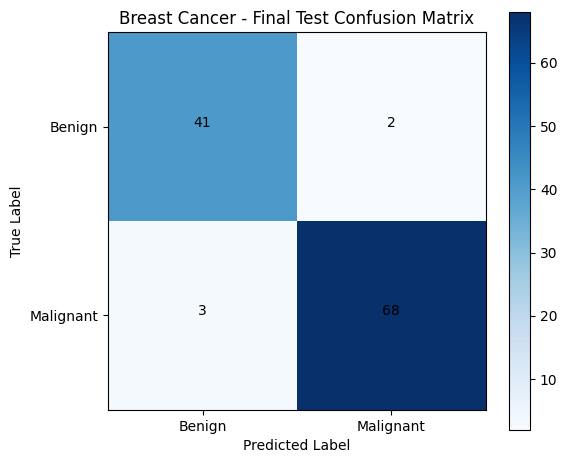

In [ ]:
plot_confusion_matrix(cm_bc, ["Benign", "Malignant"],
                      title="Breast Cancer - Final Test Confusion Matrix")


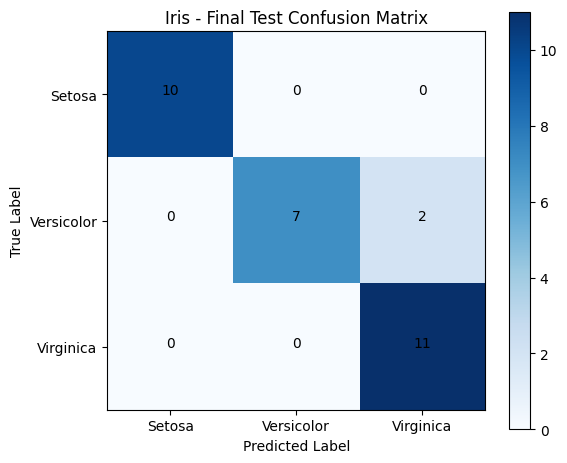

In [83]:
plot_confusion_matrix(cm_iris, ["Setosa", "Versicolor", "Virginica"],
                      title="Iris - Final Test Confusion Matrix")


# Conclusión

Realizamos una búsqueda sistemática de hiperparámetros para encontrar la configuración óptima en cada dataset. Para Breast Cancer, la mejor combinación fue L=1, batch size=128 y λ=0.001, mientras que para Iris fue L=15, batch size=128 y λ=0.0, ambos con Leaky ReLU como función de activación. 


Los modelos obtenidos lograron alta precisión en test con buena generalización, demostrando que la optimización de hiperparámetros permitió adaptar la complejidad del modelo a las características específicas de cada problema.

---